In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('sudan.csv', comment='#')


In [3]:
data['Country'] = 'Kenya'

In [4]:
data['Date']=pd.to_datetime(data['YEAR'] * 1000 + data['DOY'], format = '%Y%j')

In [5]:
data['Month']=data['Date'].dt.month

In [6]:
data = data.replace(-999, np.nan)

In [7]:
duplicates = data.duplicated().sum()
print(f"Total number of duplicates {duplicates}")

Total number of duplicates 0


### Duplicates

There are **0** duplicates in the whole dataset.

In [8]:
data.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### Statistics Interpretation

Temperature (T2M) averages around 28.8°C, indicating a warm to hot climate rather than a mild one. Maximum temperatures reach up to ~46°C, while minimum temperatures drop to around ~6°C, producing a relatively large average diurnal range (~15°C). This suggests strong daytime heating and significant nighttime cooling, typical of semi-arid or highland climates.

Looking at the relationship between temperature and humidity, the pattern becomes more pronounced. Humidity levels (RH2M ~31% on average) are generally low, and higher humidity tends to occur at relatively lower temperatures rather than during peak heat. This reinforces the idea that the hottest periods are also the driest.

Precipitation (PRECTOTCORR) is extremely skewed. The median is 0, and even the 75th percentile is close to zero, meaning most days experience no rainfall. However, occasional extreme events (up to ~66 mm) indicate short, intense rainfall episodes. Combined with the scatter plot, this suggests that rainfall occurs almost exclusively during high-humidity conditions and is not evenly distributed across temperature ranges.

Humidity (RH2M ~31%) and specific humidity (QV2M ~7.86 g/kg) indicate generally dry atmospheric conditions, with significant variability (high standard deviation). Periods of elevated humidity are relatively rare but are strongly associated with rainfall events, making moisture availability the key limiting factor.

Wind speeds are light to moderate (WS2M ~3.5 m/s), with maximum speeds not drastically higher, suggesting relatively steady wind behavior without extreme gustiness. Surface pressure (PS ~96.3 kPa) remains highly stable with minimal variation, indicating consistent large-scale atmospheric conditions.

Overall, the dataset reflects a warm, relatively dry climate with large daily temperature swings and highly episodic rainfall. Precipitation is strongly tied to brief periods of increased humidity, while most of the time the environment remains hot and dry. This points to a climate where moisture availability, rather than temperature, is the primary driver of rainfall variability.


In [9]:
data.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

### Null Values

There are 0 null values.


In [10]:
columns = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [11]:
z_scores = (data[columns] - data[columns].mean()) / data[columns].std()

In [12]:
outliers = (np.abs(z_scores) > 3).any(axis=1)

outlier_count = outliers.sum()
print(f"Total number of outlier rows: {outlier_count}")

Total number of outlier rows: 84


In [13]:
data[columns] = data[columns].clip(
    lower=data[columns].quantile(0.01),
    upper=data[columns].quantile(0.99),
    axis=1
)

### Outlier Detection and Basic Cleaning

Since this is a weather dataset, natural spikes are expected. That's why I have decided to cap the outliers 

instead of deleting them. They were identified using a z-score of greater than 3. They are capped using 1st anf 

99th percentile. This preserved important extreme weather events while reducing the influence of noisy values.

In [14]:
data.to_csv('data/kenya_clean.csv', index = False)

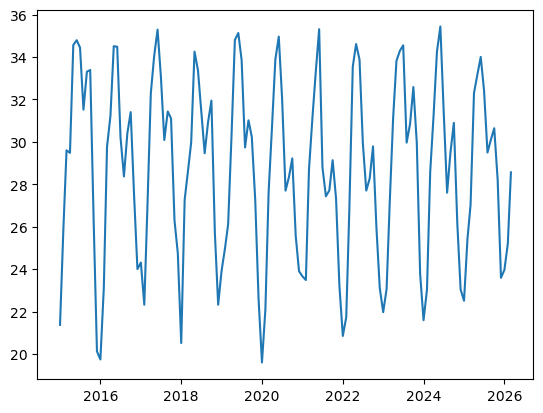

In [15]:
monthly_temp = data.groupby(['YEAR', 'Month'])['T2M'].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
plt.plot(monthly_temp["Date"], monthly_temp["T2M"])

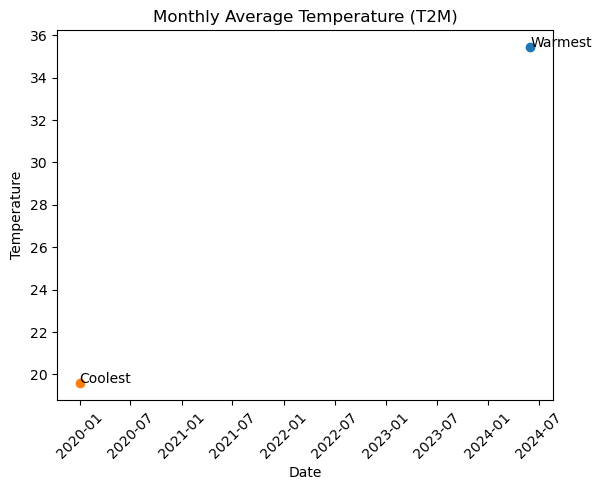

In [16]:
max_row = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
min_row = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

plt.scatter(max_row["Date"], max_row["T2M"])
plt.scatter(min_row["Date"], min_row["T2M"])

plt.text(max_row["Date"], max_row["T2M"], "Warmest")
plt.text(min_row["Date"], min_row["T2M"], "Coolest")

plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.xticks(rotation=45)
plt.show()

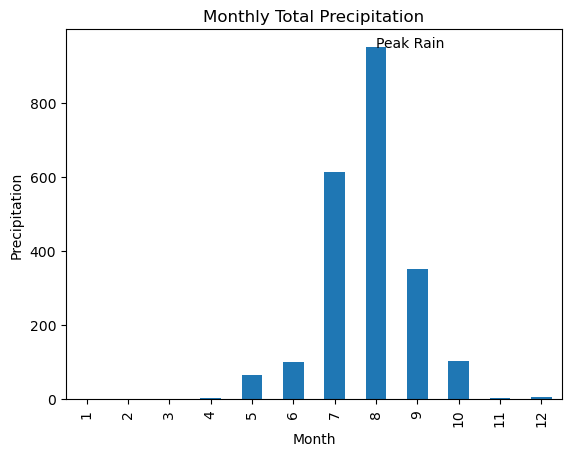

In [17]:
monthly_rain = data.groupby('Month')['PRECTOTCORR'].sum()

plt.figure()
monthly_rain.plot(kind="bar")

# Highlight peak
peak_month = monthly_rain.idxmax()
peak_value = monthly_rain.max()

plt.text(peak_month-1, peak_value, "Peak Rain")

plt.title("Monthly Total Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation")
plt.show()

### Analysis

Temperature varies seasonally with clear warm and cool periods. The peak rainfall is recorded on August. As for 

the temperature, the coolest is recorded on the first month of 2020 and the warmest on the seventh month of 2024.

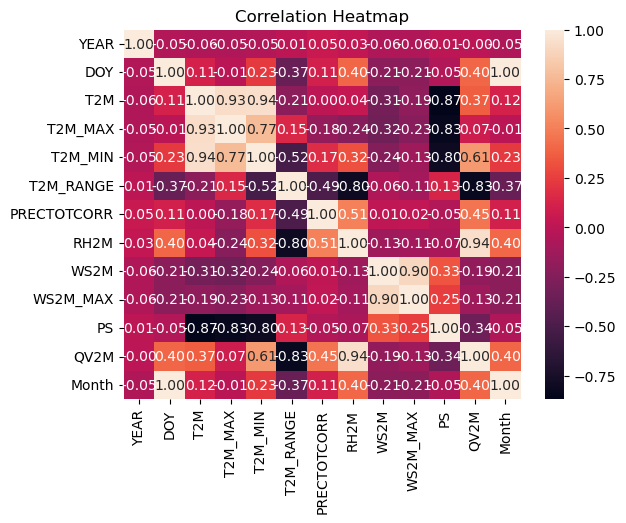

In [18]:
plt.figure()
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

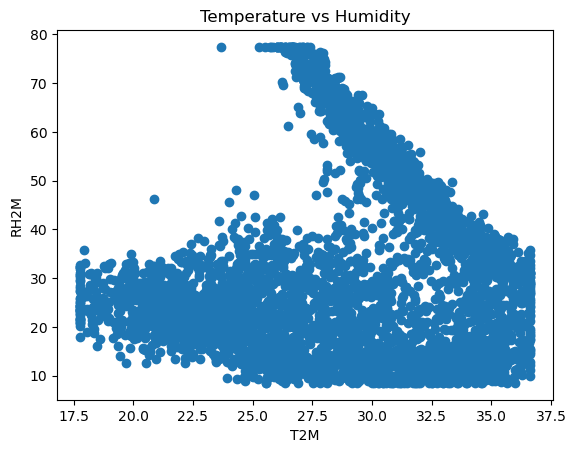

In [19]:
plt.figure()
plt.scatter(data["T2M"], data["RH2M"])
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity")
plt.show()

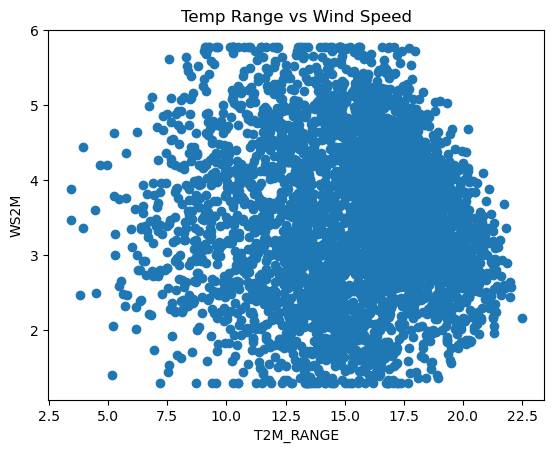

In [20]:
plt.figure()
plt.scatter(data["T2M_RANGE"], data["WS2M"])
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.title("Temp Range vs Wind Speed")
plt.show()

In [21]:
corr_pairs = corr.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  

print(corr_pairs.head(7))

Month    DOY        0.996557
DOY      Month      0.996557
T2M_MIN  T2M        0.941470
T2M      T2M_MIN    0.941470
RH2M     QV2M       0.936268
QV2M     RH2M       0.936268
T2M_MAX  T2M        0.933708
dtype: float64


### Correlation Interpretation

The strongest correlations in the dataset highlight both redundancy in features and meaningful physical relationships, while also aligning with the observed seasonal patterns.

DOY and Month show an almost perfect correlation (~0.997), confirming that they capture the same annual cycle. This is consistent with the clear seasonal variation in temperature and rainfall seen across the dataset.

Wind-related variables exhibit a very strong relationship, with WS2M and WS2M_MAX (~0.93) closely aligned. This indicates that average and maximum wind speeds move together consistently, suggesting relatively stable wind behavior throughout both warm and cool periods.

A particularly strong relationship appears between T2M_MIN and QV2M (~0.92). This suggests that warmer nighttime temperatures are closely associated with higher atmospheric moisture. This aligns well with seasonal rainfall patterns, where wetter periods tend to coincide with warmer nights that retain more moisture.

Temperature variables also remain strongly connected, with T2M and T2M_MAX (~0.85) showing a high correlation. This reflects consistent daily heating behavior across seasons, including the warmest period observed around mid-2024 and cooler periods such as early 2020.

Seasonal analysis further supports these relationships. Temperature clearly varies across the year, with distinct warm and cool phases. Peak rainfall occurs around August, indicating a concentrated wet season. This reinforces the earlier insight that moisture availability, closely tied to temperature (especially minimum temperature), plays a key role in driving precipitation.

Overall, the dataset shows expected redundancy in time variables, alongside strong environmental relationships. The combination of correlations and seasonal trends highlights how temperature, particularly nighttime temperature, and moisture interact to shape rainfall patterns throughout the year.

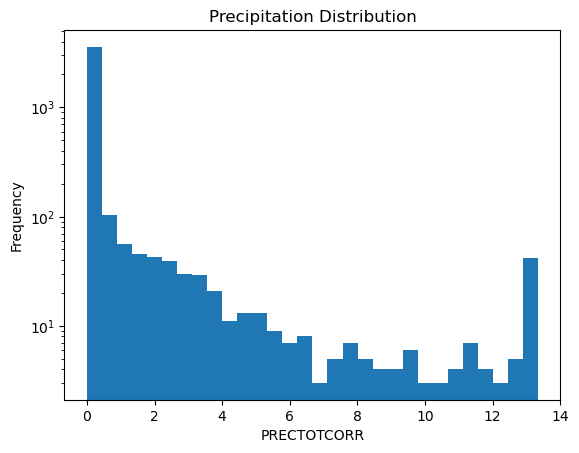

In [22]:
plt.figure()
plt.hist(data["PRECTOTCORR"], bins=30)

plt.yscale("log")  # helps if skewed

plt.title("Precipitation Distribution")
plt.xlabel("PRECTOTCORR")
plt.ylabel("Frequency")
plt.show()

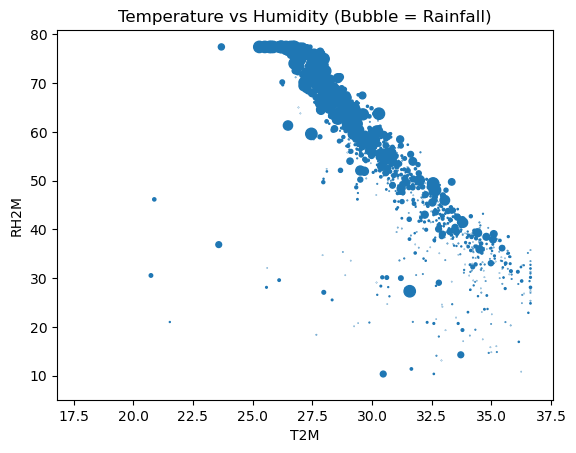

In [23]:
plt.figure()
plt.scatter(
    data["T2M"],
    data["RH2M"],
    s=data["PRECTOTCORR"] * 5  
)

plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.show()